In [1]:
import os



import numpy as np

from tensorflow.keras.preprocessing.image import load_img, img_to_array
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

2025-04-30 05:23:43.253851: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-30 05:23:43.607709: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-30 05:23:43.729998: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745990623.956192   38691 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745990624.060208   38691 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745990624.700007   38691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:



# Define paths

import shutil

def organize_images():
    # Define the paths
    train_dir = "data/raw/train"
    cat_dir = os.path.join(train_dir, "cat")
    dog_dir = os.path.join(train_dir, "dog")

    # Create directories if they don't exist
    os.makedirs(cat_dir, exist_ok=True)
    os.makedirs(dog_dir, exist_ok=True)

    # Iterate over the files in the train directory
    for filename in os.listdir(train_dir):
        file_path = os.path.join(train_dir, filename)
        if os.path.isfile(file_path):  # Ensure it's a file
            if filename.startswith("cat"):
                shutil.move(file_path, os.path.join(cat_dir, filename))
            elif filename.startswith("dog"):
                shutil.move(file_path, os.path.join(dog_dir, filename))

    print("Images organized successfully.")

if __name__ == "__main__":
    organize_images()



Images organized successfully.


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
train_dir = "./data/raw/train"
test_dir = "./data/raw/test"

# Create ImageDataGenerator for training and test sets
train_datagen = ImageDataGenerator(rescale=1./255,  # Normalize pixel values
                                   rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
                                   shear_range=0.2, zoom_range=0.2, horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)  # Only normalize test images

# Load training images (cat=0, dog=1)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(200, 200),  # Resize to 200x200
    batch_size=32,
    class_mode='binary',  # Binary classification (dog=1, cat=0)
    shuffle=True
)

# Load test images (no labels)
test_generator = test_datagen.flow_from_directory(
    directory="./raw",
    classes=["test"],
    target_size=(200, 200),
    batch_size=32,
    class_mode=None,  # No labels for test set
    shuffle=False
)



Found 25000 images belonging to 2 classes.
Found 0 images belonging to 1 classes.


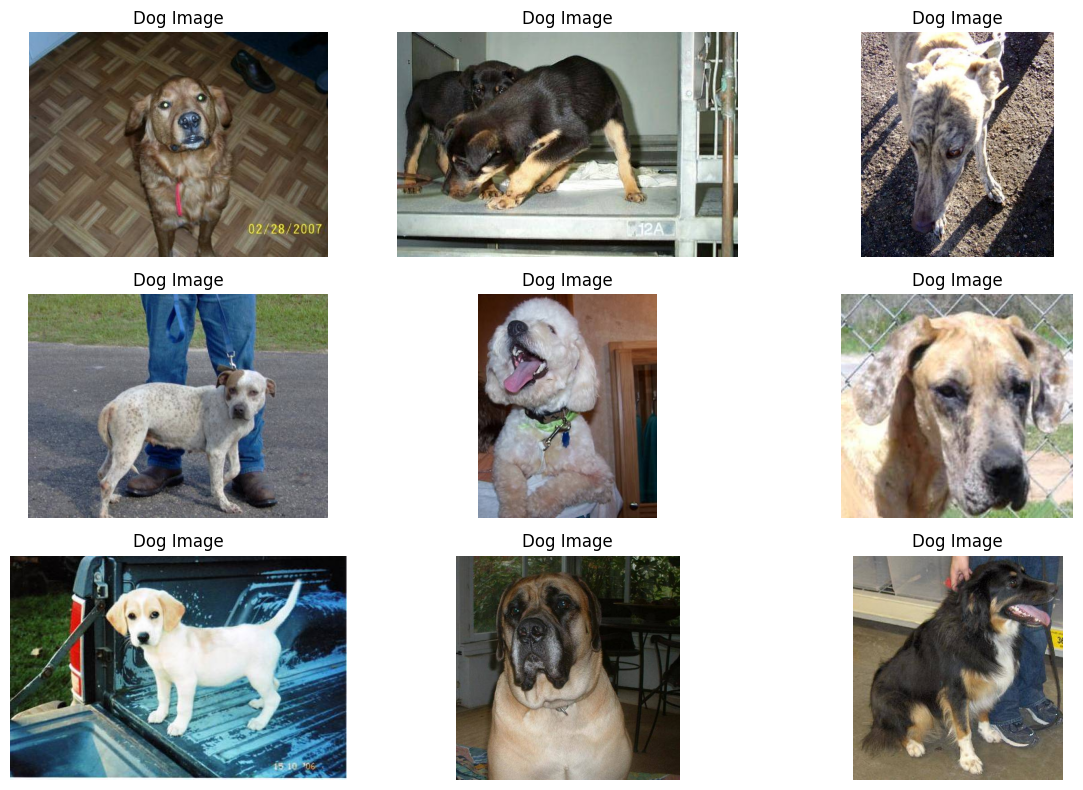

In [4]:
data_dir = "./data/raw/train/dog"

# Get a list of all dog image file names
dog_subfolder = os.path.join(data_dir)

# Get a list of all dog image file names
dog_image_files = os.listdir(dog_subfolder)

# Load the first nine dog images
dog_images = []
for i in range(min(9,len(dog_image_files))):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Adjust target_size as needed
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalize pixel values to [0, 1]
    dog_images.append(img_array)

# Create a single figure to display all nine images
plt.figure(figsize=(12, 8))

for i in range(len(dog_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()



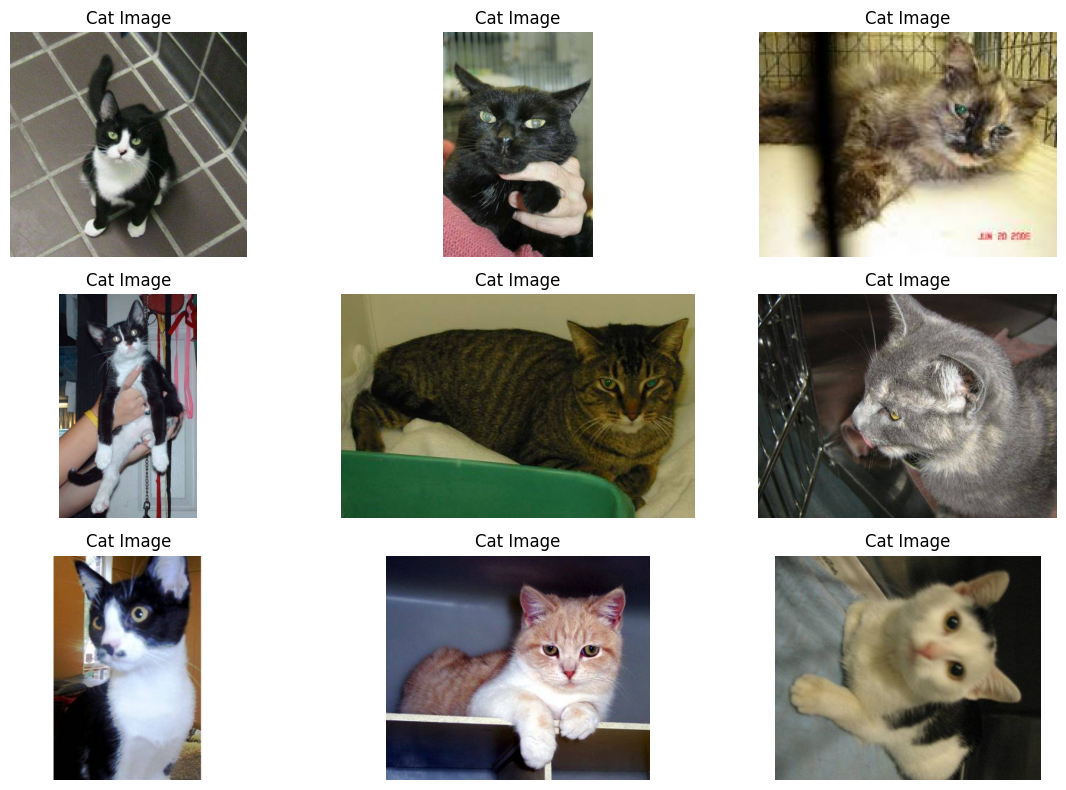

In [5]:
data_dir = "./data/raw/train/cat"

# Get a list of all cat image file names
cats_subfolder = os.path.join(data_dir)

# Get a list of all Cat image file names
cats_image_files = os.listdir(cats_subfolder)

# Load the first nine cat images
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limit to available cat images
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Create a single figure to display all cat images
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load the training data
train_data = image_dataset_from_directory(
    "./data/raw/train",  # Parent directory containing 'dog' and 'cat' folders
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(200, 200),
    batch_size=32
)

# Load the validation data
validation_data = image_dataset_from_directory(
    "./data/raw/train",  # Parent directory containing 'dog' and 'cat' folders
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(200, 200),
    batch_size=32
)

print("Training and validation data loaded successfully.")



Found 25000 files belonging to 2 classes.
Using 20000 files for training.


2025-04-30 05:23:54.946648: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Training and validation data loaded successfully.


In [7]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, BatchNormalization, Activation, Dropout

model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))  # Adjust output for 2 classes

print("Model defined successfully.")

Model defined successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-30 05:23:56.116238: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40960000 exceeds 10% of free system memory.
2025-04-30 05:23:56.170753: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40960000 exceeds 10% of free system memory.
2025-04-30 05:23:56.196109: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40960000 exceeds 10% of free system memory.


In [8]:
from keras.optimizers import Adam

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [14]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.preprocessing import image

# Define callbacks
checkpoint = ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
earlystop = EarlyStopping(monitor="val_accuracy", patience=5, verbose=1)


hist = model.fit(
    train_data,  
    steps_per_epoch=50,  
    validation_data=validation_data,  
    validation_steps=10,  
    epochs=3,  
    callbacks=[checkpoint, earlystop]  
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5687 - loss: 0.7155
Epoch 1: val_accuracy improved from -inf to 0.54688, saving model to best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.5684 - loss: 0.7152 - val_accuracy: 0.5469 - val_loss: 0.6918
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5391 - loss: 0.7046
Epoch 2: val_accuracy improved from 0.54688 to 0.55313, saving model to best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.5391 - loss: 0.7046 - val_accuracy: 0.5531 - val_loss: 0.6886
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5165 - loss: 0.7019
Epoch 3: val_accuracy did not improve from 0.55313
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.5164 - loss: 0.7019 - val_accuracy: 0.5188 - val_loss: 0.6930


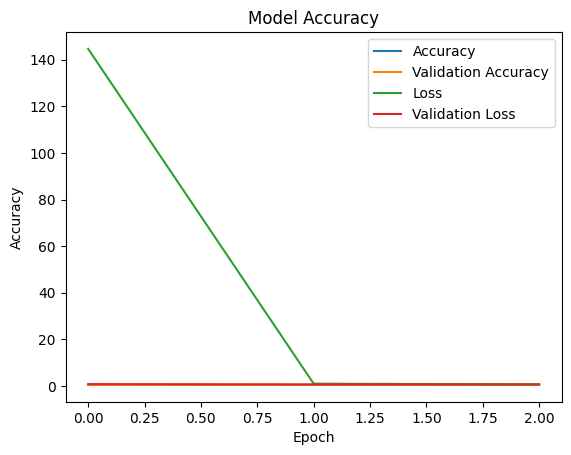

In [10]:
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])

# Configure the Plot Layout
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

# Plot
plt.show()

In [11]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(), metrics=['accuracy'])
print("Model compiled successfully.")

Model compiled successfully.


In [12]:
model.save("final_model.keras")
print("Model saved successfully.")

Model saved successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


dog


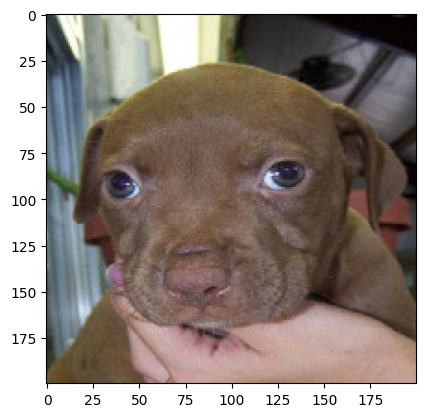

In [13]:
from keras.preprocessing import image
from keras.models import load_model
import numpy as np

import random
random_animal = random.randint(1,12500)
filename = f"{random_animal}.jpg"
img = image.load_img(f"./data/raw/test/{filename}", target_size = (200, 200))
img = np.asarray(img)
plt.imshow(img)
img = np.expand_dims(img, axis = 0)
saved_model = load_model("./final_model.keras")
output = saved_model.predict(img)
if output[0][0] > output[0][1]:
    print("cat")
else:
    print("dog")
